In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.manifold import TSNE
import umap
import warnings
warnings.filterwarnings('ignore')

# EDA

In [4]:
data = pd.read_csv("creditcard.csv")
data

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [10]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [11]:
sum(data.isnull().sum())

0

In [9]:
fraud_percentage =(data['Class'].sum() / len(data)) * 100 # это сколько мошеннических транзакций на 100 транзакций
print(f"Процент мошеннических на 100 транзакций: {fraud_percentage:.2f}%")
print("Количество обычных транзакций: ", len(data[data['Class']==0]))
print("Количество мошеннических транзакций: ", len(data[data['Class']==1]))
contamination = fraud_percentage / 100
print(f"\nЗначение contamination для моделей: {contamination:.6f}")

Процент мошеннических на 100 транзакций: 0.17%
Количество обычных транзакций:  284315
Количество мошеннических транзакций:  492

Значение contamination для моделей: 0.001727


### contamination (≈0.00172) будет использоваться для настройки параметров моделей обнаружения аномалий.
Воспользуйтесь процентом аномалий, подсчитанным по переменной Class, как "экспертной оценкой" загрязненности нашего датасета.

array([[<Axes: title={'center': 'Time'}>, <Axes: title={'center': 'V1'}>,
        <Axes: title={'center': 'V2'}>, <Axes: title={'center': 'V3'}>,
        <Axes: title={'center': 'V4'}>, <Axes: title={'center': 'V5'}>],
       [<Axes: title={'center': 'V6'}>, <Axes: title={'center': 'V7'}>,
        <Axes: title={'center': 'V8'}>, <Axes: title={'center': 'V9'}>,
        <Axes: title={'center': 'V10'}>, <Axes: title={'center': 'V11'}>],
       [<Axes: title={'center': 'V12'}>, <Axes: title={'center': 'V13'}>,
        <Axes: title={'center': 'V14'}>, <Axes: title={'center': 'V15'}>,
        <Axes: title={'center': 'V16'}>, <Axes: title={'center': 'V17'}>],
       [<Axes: title={'center': 'V18'}>, <Axes: title={'center': 'V19'}>,
        <Axes: title={'center': 'V20'}>, <Axes: title={'center': 'V21'}>,
        <Axes: title={'center': 'V22'}>, <Axes: title={'center': 'V23'}>],
       [<Axes: title={'center': 'V24'}>, <Axes: title={'center': 'V25'}>,
        <Axes: title={'center': 'V26'}>, <

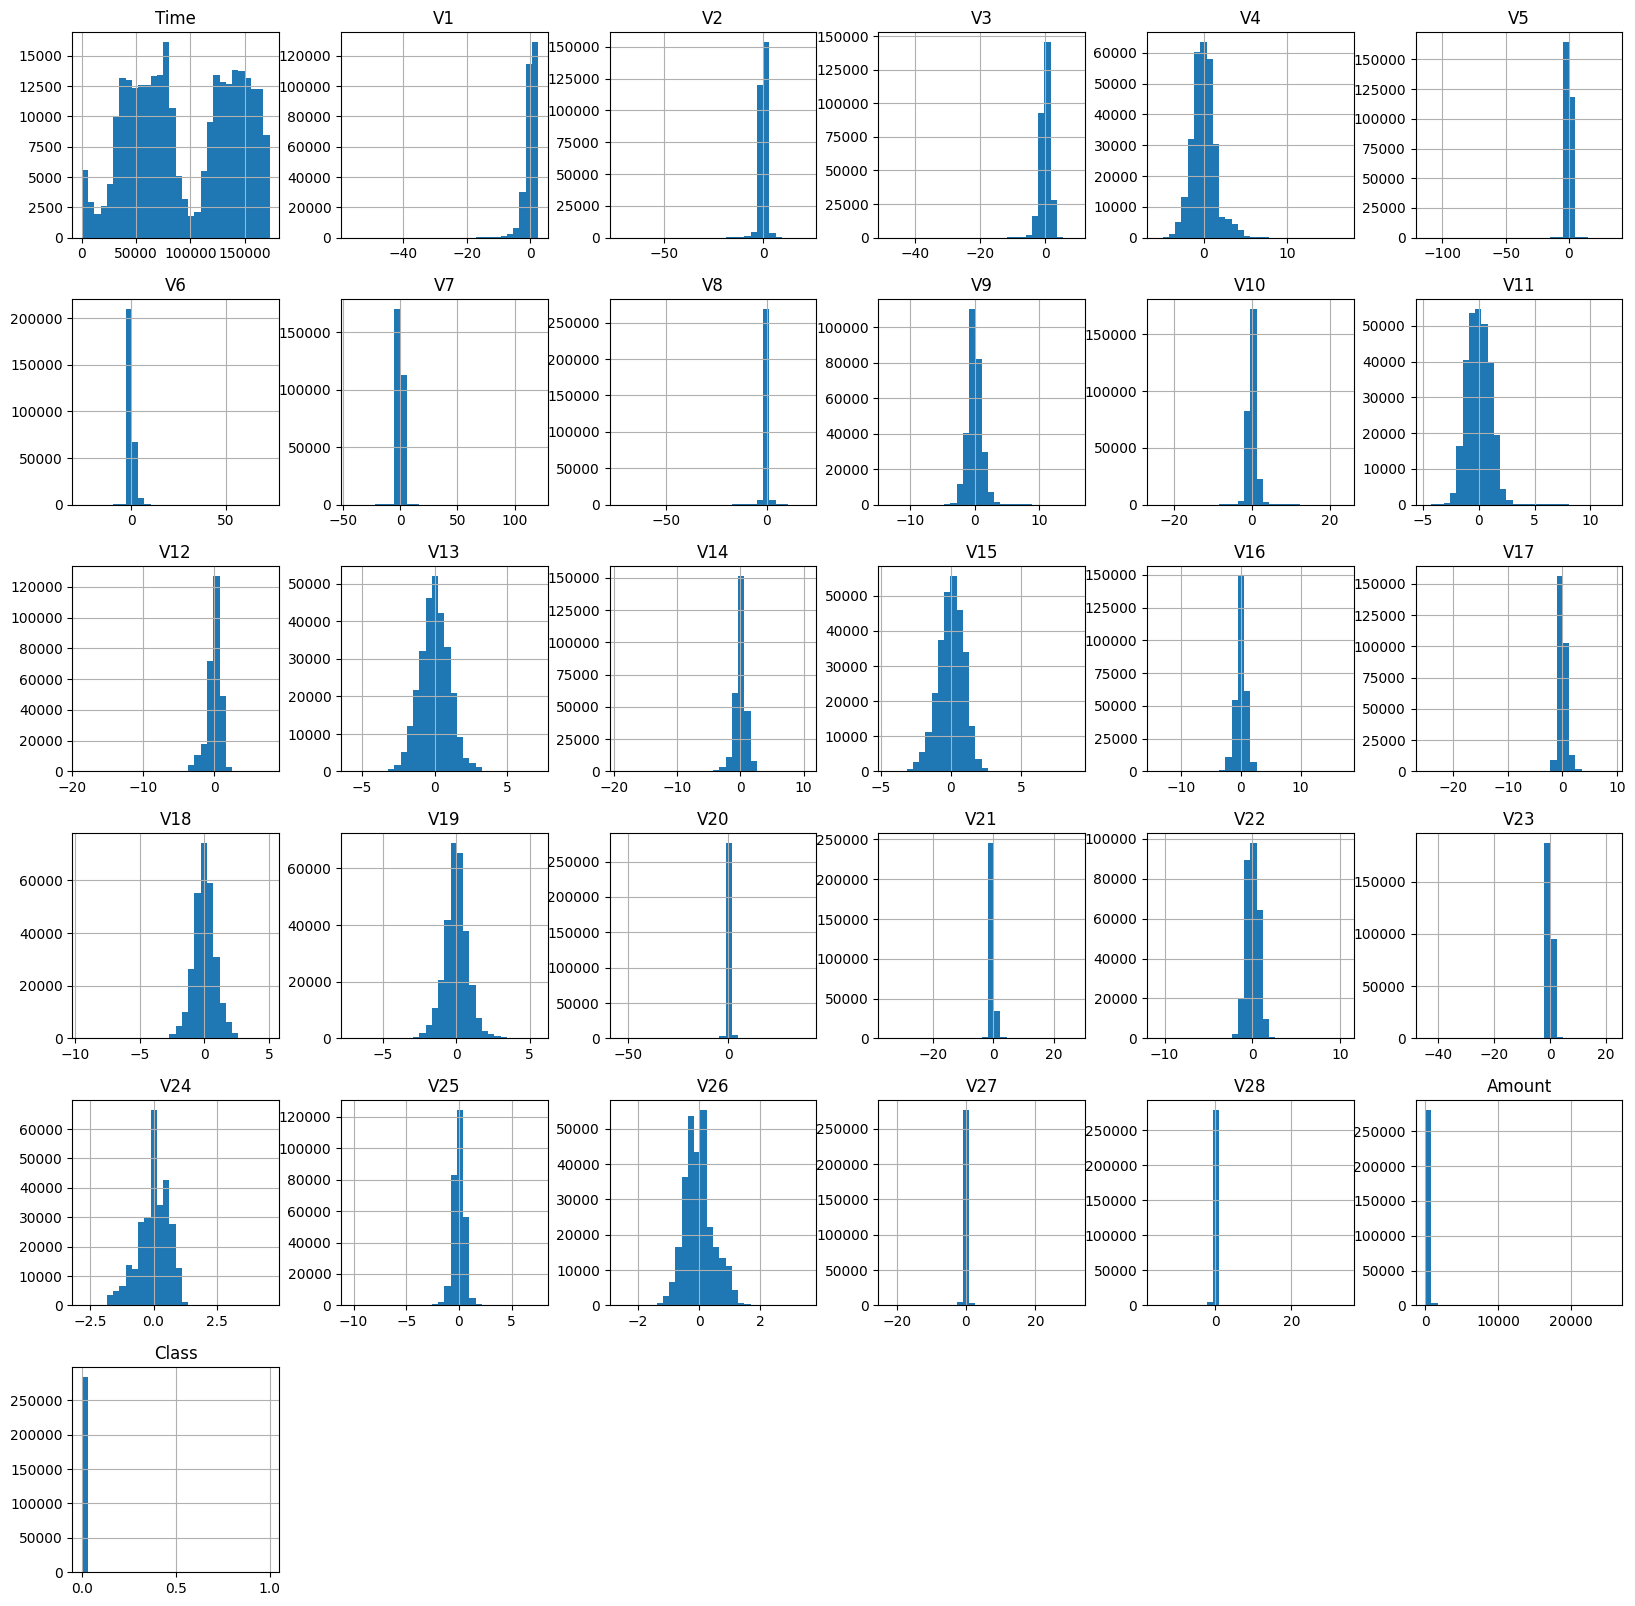

In [12]:
data.hist(figsize=(20, 20), bins =30)

In [13]:
# Разделяем на обычные и мошеннические транзакции
normal = data[data['Class'] == 0]
fraud = data[data['Class'] == 1]

print("=" * 60)
print("АНАЛИЗ РАСПРЕДЕЛЕНИЯ AMOUNT")
print("=" * 60)

print("\nСтатистика Amount для ОБЫЧНЫХ транзакций:")
print(normal['Amount'].describe())

print("\nСтатистика Amount для МОШЕННИЧЕСКИХ транзакций:")
print(fraud['Amount'].describe())

АНАЛИЗ РАСПРЕДЕЛЕНИЯ AMOUNT

Статистика Amount для ОБЫЧНЫХ транзакций:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

Статистика Amount для МОШЕННИЧЕСКИХ транзакций:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


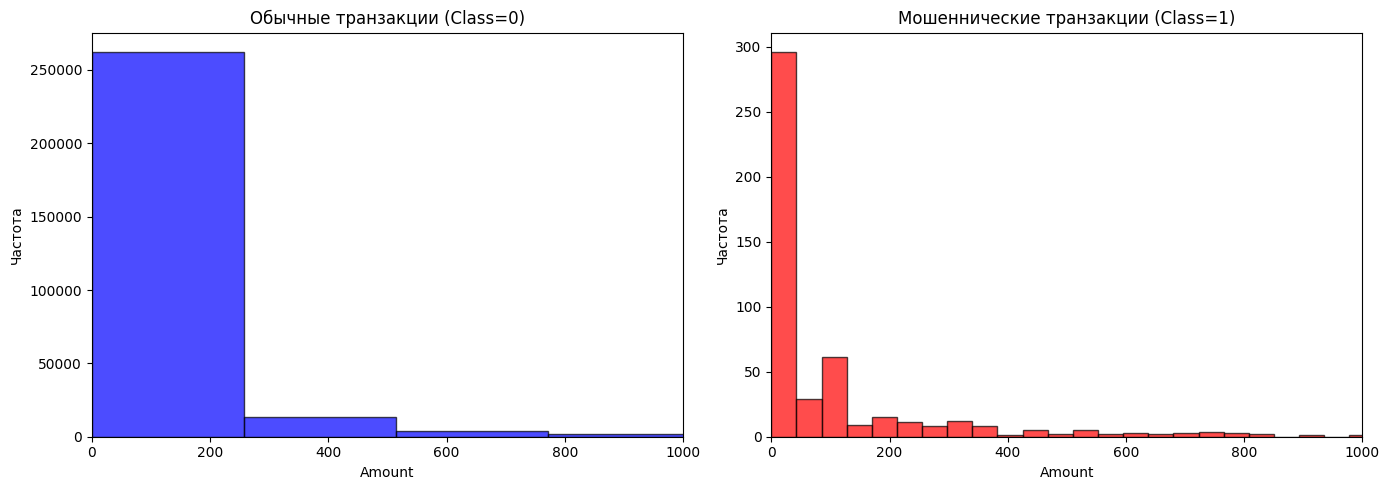

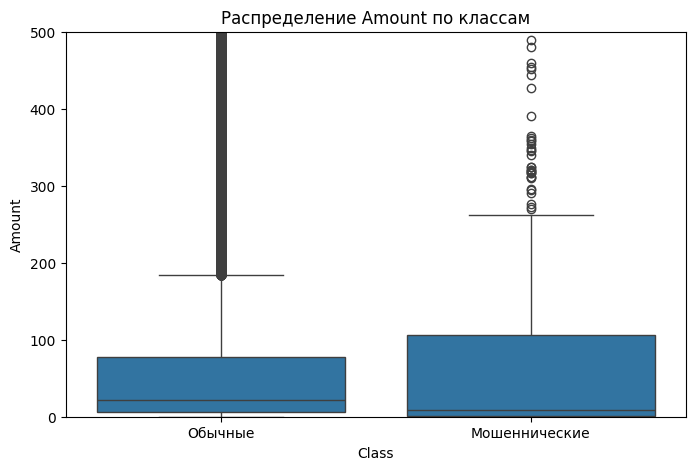

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограммы
axes[0].hist(normal['Amount'], bins=100, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_title('Обычные транзакции (Class=0)')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Частота')
axes[0].set_xlim(0, 1000)  # Ограничим для наглядности

axes[1].hist(fraud['Amount'], bins=50, alpha=0.7, color='red', edgecolor='black')
axes[1].set_title('Мошеннические транзакции (Class=1)')
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('Частота')
axes[1].set_xlim(0, 1000)

plt.tight_layout()
plt.show()

# Боксплоты для сравнения
plt.figure(figsize=(8, 5))
sns.boxplot(x='Class', y='Amount', data=data)
plt.title('Распределение Amount по классам')
plt.xticks([0, 1], ['Обычные', 'Мошеннические'])
plt.ylim(0, 500)
plt.show()


АНАЛИЗ РАСПРЕДЕЛЕНИЯ TIME

Статистика Time для ОБЫЧНЫХ транзакций:
count    284315.000000
mean      94838.202258
std       47484.015786
min           0.000000
25%       54230.000000
50%       84711.000000
75%      139333.000000
max      172792.000000
Name: Time, dtype: float64

Статистика Time для МОШЕННИЧЕСКИХ транзакций:
count       492.000000
mean      80746.806911
std       47835.365138
min         406.000000
25%       41241.500000
50%       75568.500000
75%      128483.000000
max      170348.000000
Name: Time, dtype: float64


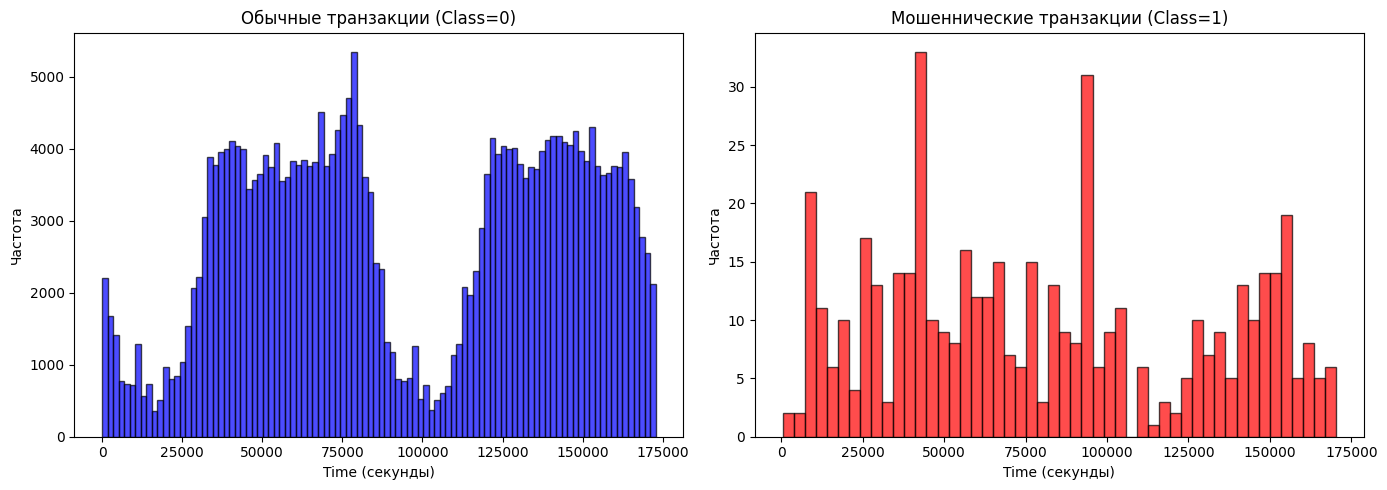

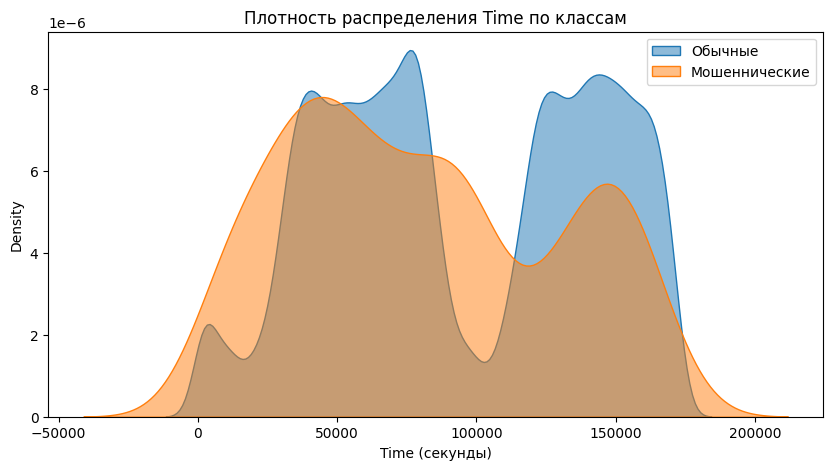

In [15]:
print("\n" + "=" * 60)
print("АНАЛИЗ РАСПРЕДЕЛЕНИЯ TIME")
print("=" * 60)

print("\nСтатистика Time для ОБЫЧНЫХ транзакций:")
print(normal['Time'].describe())

print("\nСтатистика Time для МОШЕННИЧЕСКИХ транзакций:")
print(fraud['Time'].describe())

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(normal['Time'], bins=100, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_title('Обычные транзакции (Class=0)')
axes[0].set_xlabel('Time (секунды)')
axes[0].set_ylabel('Частота')

axes[1].hist(fraud['Time'], bins=50, alpha=0.7, color='red', edgecolor='black')
axes[1].set_title('Мошеннические транзакции (Class=1)')
axes[1].set_xlabel('Time (секунды)')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

# График плотности распределения
plt.figure(figsize=(10, 5))
sns.kdeplot(normal['Time'], label='Обычные', shade=True, alpha=0.5)
sns.kdeplot(fraud['Time'], label='Мошеннические', shade=True, alpha=0.5)
plt.title('Плотность распределения Time по классам')
plt.xlabel('Time (секунды)')
plt.legend()
plt.show()


СРАВНЕНИЕ V-ПРИЗНАКОВ ПО КЛАССАМ

Средние значения V-признаков:
Признак    Обычные (среднее)    Мошеннические (среднее)   Разница   
-----------------------------------------------------------------
Time       94838.2023           80746.8069                14091.3953
V1         0.0083               -4.7719                   4.7802    
V2         -0.0063              3.6238                    3.6300    
V3         0.0122               -7.0333                   7.0455    
V4         -0.0079              4.5420                    4.5499    
V5         0.0055               -3.1512                   3.1567    
V6         0.0024               -1.3977                   1.4002    
V7         0.0096               -5.5687                   5.5784    
V8         -0.0010              0.5706                    0.5716    
V9         0.0045               -2.5811                   2.5856    


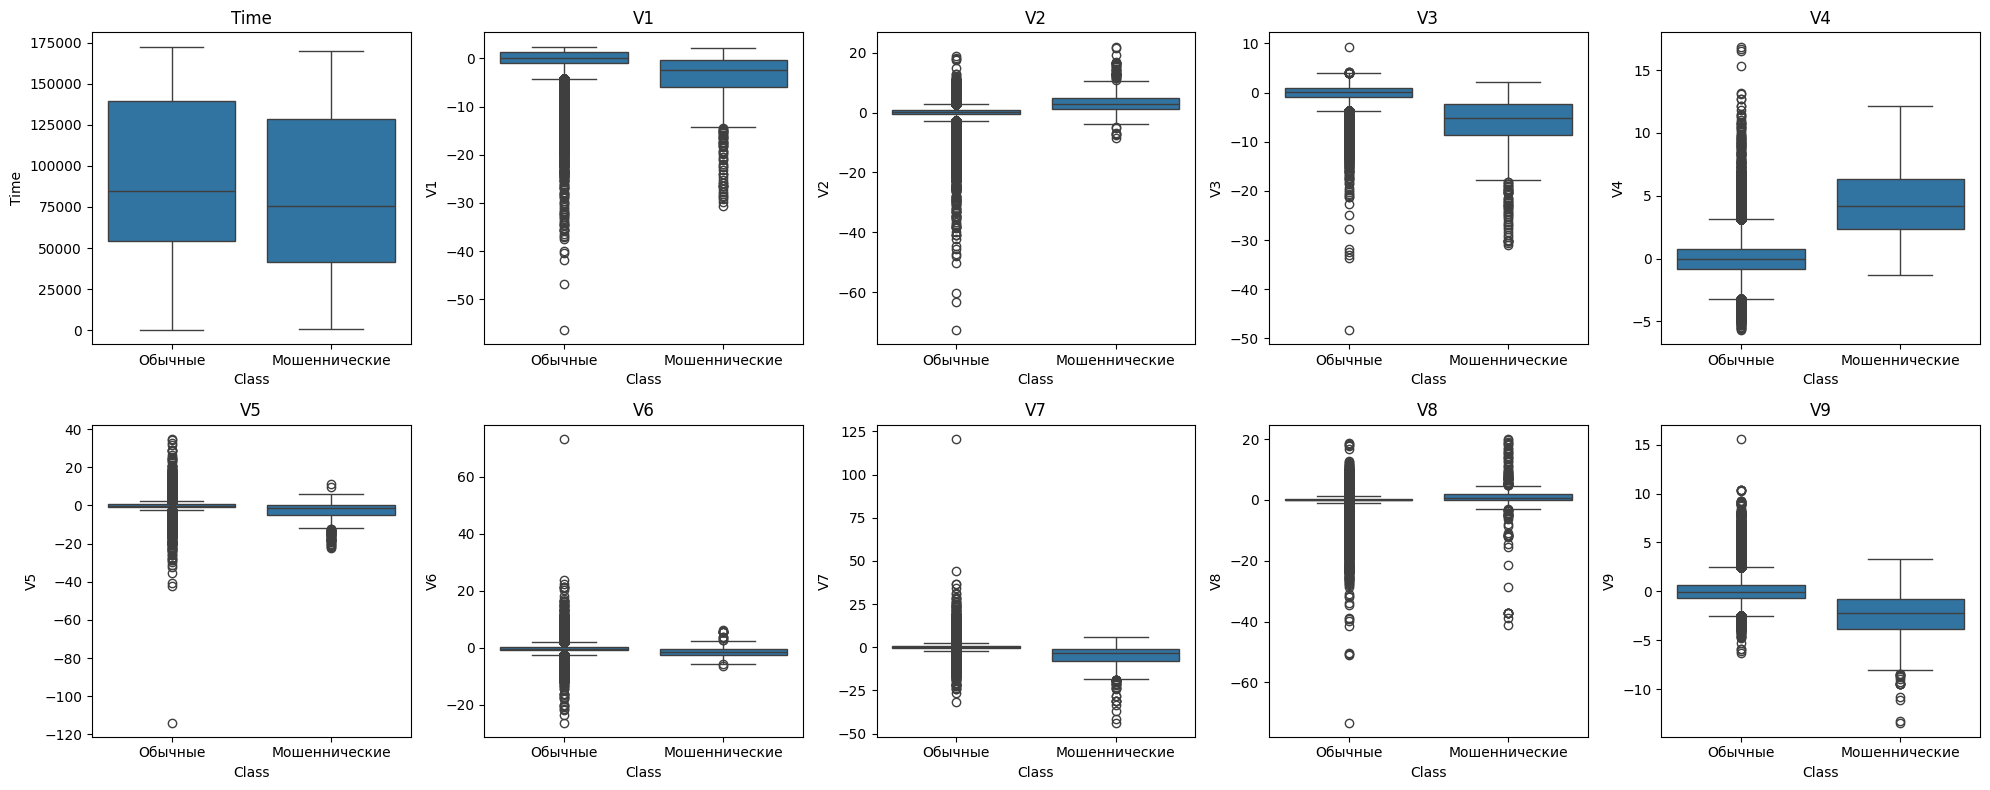

In [17]:
print("\n" + "=" * 60)
print("СРАВНЕНИЕ V-ПРИЗНАКОВ ПО КЛАССАМ")
print("=" * 60)

# Выбираем несколько V-признаков для наглядности
v_features = data.iloc[:, :-21]

print("\nСредние значения V-признаков:")
print("=" * 50)
print(f"{'Признак':<10} {'Обычные (среднее)':<20} {'Мошеннические (среднее)':<25} {'Разница':<10}")
print("-" * 65)

for v in v_features:
    mean_normal = normal[v].mean()
    mean_fraud = fraud[v].mean()
    diff = abs(mean_fraud - mean_normal)
    print(f"{v:<10} {mean_normal:<20.4f} {mean_fraud:<25.4f} {diff:<10.4f}")

# Визуализация: боксплоты для нескольких V-признаков
# fig, axes = plt.subplots(2, int(int(len(v_features.columns.to_list()))/2), figsize=(20, 8))
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, v in enumerate(v_features):
    sns.boxplot(x='Class', y=v, data=data, ax=axes[i])
    axes[i].set_title(v)
    axes[i].set_xticklabels(['Обычные', 'Мошеннические'])

plt.tight_layout()
plt.show()


Медиана у мошенников ниже — большинство мошеннических транзакций на небольшие суммы (до ~10$) <br>
Максимальная сумма мошенничества (2125$) гораздо ниже максимальной обычной (25691$) <br>
Практический вывод: Мошенники часто используют небольшие суммы, чтобы оставаться незамеченными. <br>

По времени: <br>
Время суток, когда мошеннические транзакции встречаются чаще - то на 80000/3600=22 часа <br>


Признаки	Особенности	Что делать <br>
V1-V28	Уже центрированы (среднее ~0), масштабированы (std ~1), некоррелированы	✅ Не требуют дополнительной обработки <br>
Amount	Сильно скошен, есть выбросы, разные масштабы	🔧 Нужно масштабировать (RobustScaler — устойчив к выбросам) <br>
Time	Есть суточная цикличность, большой разброс значений	🔧 Нужно масштабировать (для SVM, LOF — обязательно) <br>
Class	Используем только для оценки качества, не для обучения	✅ Не трогаем

In [5]:
X = data.drop('Class', axis=1)
y = data['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# обучаемся только на нормальных транзакциях
X_train_normal = X_train[y_train == 0].copy()

# копии для масштабирования
X_train_normal_processed = X_train_normal.copy()
X_test_processed = X_test.copy()

scaler = RobustScaler()
X_train_normal_processed[['Time', 'Amount']] = scaler.fit_transform(
    X_train_normal[['Time', 'Amount']]
)
X_test_processed[['Time', 'Amount']] = scaler.transform(
    X_test[['Time', 'Amount']]
)

In [6]:
contamination = data['Class'].mean()   # ~0.00172

# Isolation Forest
iso_forest = IsolationForest(
    contamination=contamination,
    random_state=42,
    n_estimators=100
)
iso_forest.fit(X_train_normal)

# One-Class SVM
svm_oc = OneClassSVM(
    nu=contamination,   # или немного больше
    kernel='rbf',
    gamma='scale'
)
svm_oc.fit(X_train_normal_processed)

# LOF
lof = LocalOutlierFactor(
    contamination=contamination,
    novelty=True,
    n_neighbors=20
)
lof.fit(X_train_normal_processed)

,"n_neighbors n_neighbors: int, default=20Number of neighbors to use by default for :meth:`kneighbors` queries.If n_neighbors is larger than the number of samples provided,all samples will be used.",20
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf is size passed to :class:`BallTree` or :class:`KDTree`. This canaffect the speed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float, default=2Parameter for the Minkowski metric from:func:`sklearn.metrics.pairwise_distances`. When p = 1, thisis equivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. When fitting this is used to define thethreshold on the scores of the samples.- if 'auto', the threshold is determined as in the original paper,- if a float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",np.float64(0....7485630620034)
,"novelty novelty: bool, default=FalseBy default, LocalOutlierFactor is only meant to be used for outlierdetection (novelty=False). Set novelty to True if you want to useLocalOutlierFactor for novelty detection. In this case be aware thatyou should only use predict, decision_function and score_sampleson new unseen data and not on the training set; and note that theresults obtained this way may differ from the standard LOF results... versionadded:: 0.20",True
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [7]:
y_pred_if = (iso_forest.predict(X_test) == -1).astype(int)
y_pred_svm = (svm_oc.predict(X_test_processed) == -1).astype(int)
y_pred_lof = (lof.predict(X_test_processed) == -1).astype(int)

print("Isolation Forest:")
print(classification_report(y_test, y_pred_if))

print("\nOne-Class SVM:")
print(classification_report(y_test, y_pred_svm))

print("\nLocal Outlier Factor:")
print(classification_report(y_test, y_pred_lof))

Isolation Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.21      0.24      0.22       148

    accuracy                           1.00     85443
   macro avg       0.61      0.62      0.61     85443
weighted avg       1.00      1.00      1.00     85443


One-Class SVM:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     85295
           1       0.15      0.74      0.25       148

    accuracy                           0.99     85443
   macro avg       0.57      0.87      0.62     85443
weighted avg       1.00      0.99      0.99     85443


Local Outlier Factor:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.01      0.01      0.01       148

    accuracy                           1.00     85443
   macro avg       0.50      0.50      0.50     85443
weighted avg     

In [8]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Подбор nu для One-Class SVM:\n")

for nu_multiplier in [1, 2, 3, 5]:
    nu_value = contamination * nu_multiplier

    svm_tmp = OneClassSVM(
        nu=nu_value,
        kernel="rbf",
        gamma="scale"
    )
    svm_tmp.fit(X_train_normal_processed)

    y_pred_tmp = (svm_tmp.predict(X_test_processed) == -1).astype(int)

    precision = precision_score(y_test, y_pred_tmp, zero_division=0)
    recall = recall_score(y_test, y_pred_tmp, zero_division=0)
    f1 = f1_score(y_test, y_pred_tmp, zero_division=0)

    print(
        f"nu = {nu_value:.5f} (x{nu_multiplier}): "
        f"precision={precision:.3f}, recall={recall:.3f}, f1={f1:.3f}"
    )

Подбор nu для One-Class SVM:

nu = 0.00173 (x1): precision=0.147, recall=0.743, f1=0.245
nu = 0.00345 (x2): precision=0.147, recall=0.750, f1=0.246
nu = 0.00518 (x3): precision=0.146, recall=0.770, f1=0.245
nu = 0.00864 (x5): precision=0.122, recall=0.797, f1=0.211


Был выполнен подбор параметра nu для модели One-Class SVM. При увеличении nu модель помечала больше объектов как аномальные, поэтому recall по мошенническим транзакциям рос, однако precision постепенно снижался. Наилучший баланс между precision и recall был получен при nu = 0.00345 (x2 от экспертной contamination): precision = 0.147, recall = 0.750, f1 = 0.246. При дальнейшем увеличении nu recall возрастал незначительно, но качество по f1-score уже не улучшалось, а при nu = 0.00864 наблюдалось заметное ухудшение precision. Поэтому для данной задачи оптимальным значением nu можно считать 0.00345.

# Итоговый вывод
# 
# - Isolation Forest показал слабое качество: находит лишь небольшую часть мошеннических транзакций.
# - Local Outlier Factor на этом датасете практически не справился с поиском аномалий.
# - One-Class SVM оказался лучшей моделью по recall: он находит большую долю мошеннических операций.
# - Недостаток One-Class SVM — низкий precision: модель помечает много обычных транзакций как подозрительные.
# 

### Комментариий, размышления и выводы.

RobustScaler выбирают, потому что он не чувствителен к выбросам, а в Amount выбросов очень много. Это позволяет сохранить информативность признака, не давая выбросам "испортить" масштабирование остальных значений.

Алгоритм	Почему подходит	Особенности <br>
Isolation Forest	Эффективен для выбросов в многомерных данных, не чувствителен к масштабам	Можно использовать оригинальные данные<br>
One-Class SVM	Хорошо работает, когда аномалии отделимы от нормы	Требует масштабирования, медленный на больших данных<br>
Local Outlier Factor (LOF)	Учитывает локальную плотность, может найти скрытые аномалии	Требует масштабирования, чувствителен к выбору k<br>

Алгоритм	Как работает	Плюсы для этого датасета	Минусы <br>
Isolation Forest	Случайно "режет" данные на части. Аномалии изолируются быстрее (требуют меньше разрезов)	✅ Быстрый, работает без масштабирования, хорош для многомерных данных	Может не найти аномалии, если они не отделимы случайными разрезами <br>
One-Class SVM	Находит границу вокруг "нормальных" данных. Всё, что вне границы — аномалия	✅ Хорош, когда аномалии находятся "снаружи" облака нормальных точек	❌ Медленный на больших данных, требует масштабирования<br>
LOF	Сравнивает плотность точки с соседями. Если плотность намного ниже — аномалия	✅ Находит локальные аномалии, которые могут быть скрыты	❌ Чувствителен к выбору k, требует масштабирования<br>